# 5. The Pandas package
*** 
Pandas is a Python package built on data structures and data manipulation tools designed to make data cleaning and analysis fast and convenient. Key features are:
- NumPy's style of array-based processing, especially array-based functions for data processing without for loops
- for tabular or heterogeneous data unlike Numpy which is best for homogenous (i.e., numerical) data

In [1]:
#! ipython suppress id=cf3b99eb2a384927b92a30f4ac81d2b6
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
np.random.seed(12345)
plt.rc("figure", figsize=(10, 6))
pd.options.display.max_rows = 20
pd.options.display.max_columns = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

## 5.1.1 Series
a sequence of values (1D array) with an associated array of values called the index

In [2]:
series = pd.Series([4, 7, -5, 3]) #here is a basic series with default index
series

0    4
1    7
2   -5
3    3
dtype: int64

In [3]:
series.array #looking at only the values

<PandasArray>
[4, 7, -5, 3]
Length: 4, dtype: int64

In [4]:
series.index #looking at only the indices

RangeIndex(start=0, stop=4, step=1)

In [5]:
series.index = ["Ay", "Bee", "Cee", "Dee"] #manipulation of index labels from default integers
series

Ay     4
Bee    7
Cee   -5
Dee    3
dtype: int64

In [6]:
series.index #looking at only the indices

Index(['Ay', 'Bee', 'Cee', 'Dee'], dtype='object')

In [7]:
#! ipython id=1c154eb24cd24f2c9c384792a58a1246
series2 = pd.Series([4, 7, -5, 3], index=["d", "b", "a", "c"])
series2

d    4
b    7
a   -5
c    3
dtype: int64

In [8]:
series2["a"] #print

-5

In [9]:
series2["d"] = 6 #assign

In [10]:
series2[["c", "a", "d"]] #print in order of index labels

c    3
a   -5
d    6
dtype: int64

In [ ]:
 series2[[3, 2, 0]] #print in order of indices (with warning that this behaviour will be modified in a future version)

In [12]:
Series.iloc?

Type:        property
String form: <property object at 0x0000029F530AB9A0>
Docstring:  
Purely integer-location based indexing for selection by position.

``.iloc[]`` is primarily integer position based (from ``0`` to
``length-1`` of the axis), but may also be used with a boolean
array.

Allowed inputs are:

- An integer, e.g. ``5``.
- A list or array of integers, e.g. ``[4, 3, 0]``.
- A slice object with ints, e.g. ``1:7``.
- A boolean array.
- A ``callable`` function with one argument (the calling Series or
  DataFrame) and that returns valid output for indexing (one of the above).
  This is useful in method chains, when you don't have a reference to the
  calling object, but would like to base your selection on some value.
- A tuple of row and column indexes. The tuple elements consist of one of the
  above inputs, e.g. ``(0, 1)``.

``.iloc`` will raise ``IndexError`` if a requested indexer is
out-of-bounds, except *slice* indexers which allow out-of-bounds
indexing (this conforms w

In [13]:
series2.iloc[[3, 2, 0]] #print in order of indices

c    3
a   -5
d    6
dtype: int64

In [14]:
series2[series2 > 0] #return values and indices where true (try returning only the value or index)

d    6
b    7
c    3
dtype: int64

In [15]:
series2 * 2 #scaling

d    12
b    14
a   -10
c     6
dtype: int64

In [16]:
"b" in series2 #dictionary-like operations

True

In [17]:
sdata = {"Ohio": 35000, "Texas": 71000, "Oregon": 16000, "Utah": 5000} #dictionary
series3 = pd.Series(sdata) #dictionary to Pandas series
series3

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

In [18]:
#! ipython id=a5730643a732486ead3db1e8ae3ed8c7
series3.to_dict() #the reverse of above

{'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}

In [19]:
states = ["California", "Ohio", "Oregon", "Texas"]
series4 = pd.Series(sdata, index=states) #custom index for the data that includes an index entry with no associated data
#and omits one of the states which is in the data (Utah)
series4

California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64

In [20]:
pd.isna(series4)
series4.isna() #alternative to the above (inherited function)

California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [21]:
pd.notna(series4)
~series4.isna() #same thing (invert operation)

California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool

In [22]:
series3, series4

(Ohio      35000
 Texas     71000
 Oregon    16000
 Utah       5000
 dtype: int64,
 California        NaN
 Ohio          35000.0
 Oregon        16000.0
 Texas         71000.0
 dtype: float64)

In [23]:
series3 + series4 #even though these are not aligned by index label, the arithmetic will add using alignment (similar to a join operation) 
#note that where an index or value does not exist, the resulting sum will have only the index.

California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64

In [24]:
series4.name = "pop" #remember this is a 1D array-like structure so there are no columns to name
series4.index.name = "state" #except the index
series4

state
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: pop, dtype: float64

## 5.1.2 DataFrame (df)
Think of this as a dictionary of Series' where they all share the same index

In [184]:
data = {"state": ["Ohio", "Ohio", "Ohio", "Nevada", "Nevada", "Nevada"],
        "year": [2000, 2001, 2002, 2001, 2002, 2003],
        "pop": [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}
frame = pd.DataFrame(data)
frame #the resulting table is ordered as implied by the dictionary it was created from

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [185]:
frame.head() #top 5

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9


In [186]:
frame.tail() #bottom 5

,state,year,pop
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [187]:
frame1 = pd.DataFrame(data, columns=["year", "state", "pop"]) #explicitly ordering the columns
frame1

,year,state,pop
0,2000,Ohio,1.5
1,2001,Ohio,1.7
2,2002,Ohio,3.6
3,2001,Nevada,2.4
4,2002,Nevada,2.9
5,2003,Nevada,3.2


In [188]:
frame2 = pd.DataFrame(data, columns=["year", "state", "pop", "diif"]) #adding a column. Debt values do not exist in data so it is NaN
frame2

,year,state,pop,diif
0,2000,Ohio,1.5,NaN
1,2001,Ohio,1.7,NaN
2,2002,Ohio,3.6,NaN
3,2001,Nevada,2.4,NaN
4,2002,Nevada,2.9,NaN
5,2003,Nevada,3.2,NaN


In [30]:
frame2["state"] #print column

0      Ohio
1      Ohio
2      Ohio
3    Nevada
4    Nevada
5    Nevada
Name: state, dtype: object

In [31]:
frame2.state #column becomes an attribute of the df but can be overrided by python attributes (avoid this approach)

0      Ohio
1      Ohio
2      Ohio
3    Nevada
4    Nevada
5    Nevada
Name: state, dtype: object

In [32]:
frame2[:][frame2.columns[1]] #another alternative to printing a column except here we don't know the column name

0      Ohio
1      Ohio
2      Ohio
3    Nevada
4    Nevada
5    Nevada
Name: state, dtype: object

In [33]:
frame2.loc[1] #return values at that index label

year     2001
state    Ohio
pop       1.7
debt      NaN
Name: 1, dtype: object

In [34]:
frame2.iloc[1] #return values at that index (note here that the indices are integers as with a normal array)

year     2001
state    Ohio
pop       1.7
debt      NaN
Name: 1, dtype: object

In [35]:
frame2["debt"] = 16.5 #change all
frame2

,year,state,pop,debt
0,2000,Ohio,1.5,16.5
1,2001,Ohio,1.7,16.5
2,2002,Ohio,3.6,16.5
3,2001,Nevada,2.4,16.5
4,2002,Nevada,2.9,16.5
5,2003,Nevada,3.2,16.5


In [36]:
frame2["debt"] = np.arange(6.0) #change each by providing a sequence of values (arange is the numpy equiv of range)
frame2

,year,state,pop,debt
0,2000,Ohio,1.5,0.0
1,2001,Ohio,1.7,1.0
2,2002,Ohio,3.6,2.0
3,2001,Nevada,2.4,3.0
4,2002,Nevada,2.9,4.0
5,2003,Nevada,3.2,5.0


In [37]:
val = pd.Series([-1.2, -1.5, -1.7], index=[2, "four", "5"]) #any values that do not exist in the index column will be discarded
frame2["debt2"] = val #columns that do not exist are created
frame2

,year,state,pop,debt,debt2
0,2000,Ohio,1.5,0.0,NaN
1,2001,Ohio,1.7,1.0,NaN
2,2002,Ohio,3.6,2.0,-1.2
3,2001,Nevada,2.4,3.0,NaN
4,2002,Nevada,2.9,4.0,NaN
5,2003,Nevada,3.2,5.0,NaN


In [38]:
frame2["Las Vegas"] = (frame2["state"] == "Nevada") #creating a new column and showing where true
frame2

,year,state,pop,debt,debt2,Las Vegas
0,2000,Ohio,1.5,0.0,NaN,False
1,2001,Ohio,1.7,1.0,NaN,False
2,2002,Ohio,3.6,2.0,-1.2,False
3,2001,Nevada,2.4,3.0,NaN,True
4,2002,Nevada,2.9,4.0,NaN,True
5,2003,Nevada,3.2,5.0,NaN,True


In [39]:
del frame2["Las Vegas"] #removing a column
frame2

,year,state,pop,debt,debt2
0,2000,Ohio,1.5,0.0,NaN
1,2001,Ohio,1.7,1.0,NaN
2,2002,Ohio,3.6,2.0,-1.2
3,2001,Nevada,2.4,3.0,NaN
4,2002,Nevada,2.9,4.0,NaN
5,2003,Nevada,3.2,5.0,NaN


In [40]:
populations = {"Ohio": {2000: 1.5, 2001: 1.7, 2002: 3.6},"Nevada": {2001: 2.4, 2002: 2.9}} #nested dictionaries where inner keys are indices 
#and outers are columns (series')
frame3 = pd.DataFrame(populations)
frame3

,Ohio,Nevada
2000,1.5,NaN
2001,1.7,2.4
2002,3.6,2.9


In [41]:
frame3.T #transpose (row/col swapping)

,2000,2001,2002
Ohio,1.5,1.7,3.6
Nevada,NaN,2.4,2.9


In [42]:
pd.DataFrame(populations, index=[2001, 2002, 2003]) #explicitly stating indices is different to the "join" approach above
#year 2000 goes missing and 2003 is NaN

,Ohio,Nevada
2001,1.7,2.4
2002,3.6,2.9
2003,NaN,NaN


In [43]:
pdata = {"Ohio": frame3["Ohio"][:-1],"Nevada": frame3["Nevada"][:2]} #take first two rows of frame 3 (complex creation of a DF)
pd.DataFrame(pdata)

C:\Users\wyngaarda\AppData\Local\Temp\ipykernel_12508\359676392.py:1: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  pdata = {"Ohio": frame3["Ohio"][:-1],"Nevada": frame3["Nevada"][:2]} #take first two rows of frame 3 (complex creation of a DF)


,Ohio,Nevada
2000,1.5,NaN
2001,1.7,2.4


In [44]:
frame3.index.name = "year" #previously we could name the index column
frame3.columns.name = "state" #now we can name the other columns in the DF
frame3

state,Ohio,Nevada
year,,
2000,1.5,NaN
2001,1.7,2.4
2002,3.6,2.9


In [45]:
frame3.to_numpy() #arrays from dataframes

array([[1.5, nan],
       [1.7, 2.4],
       [3.6, 2.9]])

In [46]:
frame2.to_numpy()

array([[2000, 'Ohio', 1.5, 0.0, nan],
       [2001, 'Ohio', 1.7, 1.0, nan],
       [2002, 'Ohio', 3.6, 2.0, -1.2],
       [2001, 'Nevada', 2.4, 3.0, nan],
       [2002, 'Nevada', 2.9, 4.0, nan],
       [2003, 'Nevada', 3.2, 5.0, nan]], dtype=object)

## 5.1.3 Index
Column and row indexes

In [47]:
obj = pd.Series(np.arange(3), index=["a", "b", "c"])
index = obj.index #index is simple an array of values
index

Index(['a', 'b', 'c'], dtype='object')

In [48]:
index[1:]

Index(['b', 'c'], dtype='object')

In [49]:
index[1] = "a" #immutable but we can reindex the DF rows or columns as we will see later

TypeError: Index does not support mutable operations

In [50]:
#! ipython id=5049c22f3b92417eab90b3edf07bbec3
labels = pd.Index(np.arange(3))
labels

Int64Index([0, 1, 2], dtype='int64')

In [51]:
#! ipython id=5049c22f3b92417eab90b3edf07bbec3
obj2 = pd.Series([1.5, -2.5, 0], index=labels) #using an array of labels as the index for one or more series
obj3 = pd.Series([2.5, -1.5, 6], index=labels) 
obj2.index is obj3.index

True

In [52]:
#! ipython id=ae6e0ad0026347e2a624f864873bdcc2
frame3

state,Ohio,Nevada
year,,
2000,1.5,NaN
2001,1.7,2.4
2002,3.6,2.9


In [53]:
#! ipython id=ae6e0ad0026347e2a624f864873bdcc2
frame3.columns

Index(['Ohio', 'Nevada'], dtype='object', name='state')

In [54]:
#! ipython id=ae6e0ad0026347e2a624f864873bdcc2
"Ohio" in frame3.columns

True

In [55]:
#! ipython id=ae6e0ad0026347e2a624f864873bdcc2
2002 in frame3.index

True

In [56]:
#! ipython id=63bf8fa08ef54a05b3b099a61cc89743
pd.Index(["foo", "foo", "bar", "bar"]) #duplicate index entries will select all duplicates when processing

Index(['foo', 'foo', 'bar', 'bar'], dtype='object')

## 5.2 Re-indexing, sorting, filtering, dropping, duplicate indices

In [57]:
obj = pd.Series([4.5, 7.2, -5.3, 3.6], index=["d", "b", "a", "c"])
obj

d    4.5
b    7.2
a   -5.3
c    3.6
dtype: float64

In [58]:
#! ipython id=5980e55c4b1f4943a6bf013a1898544a
obj2 = obj.reindex(["a", "b", "c", "d", "e"]) #reordering the index preserves the values and adds NaNs
obj2

a   -5.3
b    7.2
c    3.6
d    4.5
e    NaN
dtype: float64

In [59]:
#! ipython id=fbc0d3b6adc64be781a6d9cbb7132352
obj3 = pd.Series(["blue", "purple", "yellow"], index=[0, 2, 4])
obj3.reindex(np.arange(6), method="ffill")

0      blue
1      blue
2    purple
3    purple
4    yellow
5    yellow
dtype: object

In [60]:
#! ipython id=fbc0d3b6adc64be781a6d9cbb7132352
obj3 = pd.Series([0,5,10], index=[0, 2, 4])
obj3.reindex(np.arange(6), method="nearest")

0     0
1     5
2     5
3    10
4    10
5    10
dtype: int64

In [61]:
#! ipython id=3a2e62814cda43e6924c63d519d47591
frame = pd.DataFrame(np.arange(9).reshape((3, 3)),index=["a", "c", "d"],columns=["Ohio", "Texas", "California"])
frame

,Ohio,Texas,California
a,0,1,2
c,3,4,5
d,6,7,8


In [62]:
#! ipython id=3a2e62814cda43e6924c63d519d47591
states = ["Texas", "Utah", "California"]
frame2 = frame.reindex(index=["a", "b", "c", "d"],columns=states) #reindexing both rows and columns
frame2

,Texas,Utah,California
a,1.0,NaN,2.0
b,NaN,NaN,NaN
c,4.0,NaN,5.0
d,7.0,NaN,8.0


In [63]:
#! ipython id=6d8400ea97fd4bd8bf704f18835cada3
frame.loc[["a", "d", "c"], ["California", "Texas"]] #an alternative reindexing but the values must exist, unlike "reindex"

,California,Texas
a,2,1
d,8,7
c,5,4


In [64]:
#! ipython id=21e5021229c34d05ac9ec0dec36c506d
obj = pd.Series(np.arange(5.), index=["a", "b", "c", "d", "e"])
obj

a    0.0
b    1.0
c    2.0
d    3.0
e    4.0
dtype: float64

In [65]:
#! ipython id=21e5021229c34d05ac9ec0dec36c506d
new_obj = obj.drop("c")
new_obj

a    0.0
b    1.0
d    3.0
e    4.0
dtype: float64

In [66]:
#! ipython id=21e5021229c34d05ac9ec0dec36c506d
obj.drop(["d", "c"])

a    0.0
b    1.0
e    4.0
dtype: float64

In [67]:
#! ipython id=d6ee7bd35ad844b8b31a02cc2345e8dc
data = pd.DataFrame(np.arange(16).reshape((4, 4)),index=["Ohio", "Colorado", "Utah", "New York"],columns=["one", "two", "three", "four"])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [68]:
#! ipython id=59357e8a21f64a9fabdd36f5643dbb4f
data.drop(index=["Colorado", "Ohio"])

,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15


In [69]:
#! ipython id=d55b792ba8924524857e51d43b177489
data.drop(columns=["two"])

,one,three,four
Ohio,0,2,3
Colorado,4,6,7
Utah,8,10,11
New York,12,14,15


In [70]:
#! ipython id=4645ed672f144c4fb368d30c774f906a
data.drop(["two", "four"], axis="columns")

,one,three
Ohio,0,2
Colorado,4,6
Utah,8,10
New York,12,14


In [71]:
#! ipython id=85f497478a9d4b5e97aa8012912d1d2f
obj = pd.Series(np.arange(4.), index=["a", "b", "c", "d"])
obj

a    0.0
b    1.0
c    2.0
d    3.0
dtype: float64

In [72]:
#! ipython id=85f497478a9d4b5e97aa8012912d1d2f
obj["b":"d"] #slicing with labels includes endpoints unlike with integers

b    1.0
c    2.0
d    3.0
dtype: float64

In [73]:
#! ipython id=85f497478a9d4b5e97aa8012912d1d2f
obj[['b','d']]

b    1.0
d    3.0
dtype: float64

In [74]:
#! ipython id=655B753DAA154E1FB24039C26C83060B
obj.loc["b":"d"] #preferred over the above since loc and iloc refer to label and integer explicitly

b    1.0
c    2.0
d    3.0
dtype: float64

In [75]:
#! ipython id=FE6AE0EAF21741D8A054BEF2C9CC57C8
obj1 = pd.Series([1, 2, 3], index=[2, 0, 1])
obj2 = pd.Series([1, 2, 3], index=["a", "b", "c"])
obj1

2    1
0    2
1    3
dtype: int64

In [76]:
#! ipython id=FE6AE0EAF21741D8A054BEF2C9CC57C8
obj2

a    1
b    2
c    3
dtype: int64

In [77]:
#! ipython id=FE6AE0EAF21741D8A054BEF2C9CC57C8
obj1[[0, 1, 2]]

0    2
1    3
2    1
dtype: int64

In [78]:
#! ipython id=FE6AE0EAF21741D8A054BEF2C9CC57C8
obj2[[0, 1, 2]]

a    1
b    2
c    3
dtype: int64

In [79]:
#! ipython id=82C31C77659740BF9AF1B87B9A392659
obj1.iloc[[0, 1, 2]]

2    1
0    2
1    3
dtype: int64

In [80]:
#! ipython id=82C31C77659740BF9AF1B87B9A392659
obj2.iloc[[0, 1, 2]]

a    1
b    2
c    3
dtype: int64

In [81]:
#! ipython id=faaaebe3b978418f88cde6c84b3f7025
obj2.loc["b":"c"]

b    2
c    3
dtype: int64

In [82]:
#! ipython id=b1ef8c6f13f24aec959f541900023322
obj2.loc["b":"c"] = 5
obj2

a    1
b    5
c    5
dtype: int64

In [83]:
#! ipython id=a8c96c31128a41658f14d2442c891713
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=["Ohio", "Colorado", "Utah", "New York"],
                    columns=["one", "two", "three", "four"])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [84]:
#! ipython id=a8c96c31128a41658f14d2442c891713
data[["three", "one"]] #column access using labels

,three,one
Ohio,2,0
Colorado,6,4
Utah,10,8
New York,14,12


In [85]:
#! ipython id=dd77a40e483f4eb18dcbf506fbcc5d2a
data[:2] #row access using integers

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7


In [86]:
#! ipython id=dd77a40e483f4eb18dcbf506fbcc5d2a
data[data["three"] > 5] #selecting all data where values in col 3 are more than 5

,one,two,three,four
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [87]:
#! ipython id=9511846494a343e99600772bda5cc9e1
data > 5 #truth table of all data where values are more than 5

,one,two,three,four
Ohio,False,False,False,False
Colorado,False,False,True,True
Utah,True,True,True,True
New York,True,True,True,True


In [88]:
#! ipython id=c8be1582b25543df91106bb41cc5e7f1
data[data > 5] = 0
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,0,0
Utah,0,0,0,0
New York,0,0,0,0


In [89]:
#! ipython id=68f97d0a40964d4084df3e6c69c7750c
data.loc["Colorado"]

one      4
two      5
three    0
four     0
Name: Colorado, dtype: int32

In [90]:
#! ipython id=0f49b78471e0479b9fe9aed7b3de7c3d
data.loc[["Colorado", "New York"]]

,one,two,three,four
Colorado,4,5,0,0
New York,0,0,0,0


In [91]:
#! ipython id=5003cd2010a5468daf398166ef509b78
data.loc[["Colorado","Utah"], ["two", "three"]] #selection using labels

,two,three
Colorado,5,0
Utah,0,0


In [92]:
#! ipython id=abea7d531ec64961b975355fad10ed23
data.iloc[[1, 2], [1, 2]] #same as above but using integer indices

,two,three
Colorado,5,0
Utah,0,0


In [93]:
#! ipython id=729735e3373e433a97a215dc545059b3
data.loc[:"Utah", "two"]

Ohio        1
Colorado    5
Utah        0
Name: two, dtype: int32

In [94]:
#! ipython id=729735e3373e433a97a215dc545059b3
data.iloc[:, :3][data.three > 5] #all rows, first three columns (0,1,2) where values in col 3 are > 5

,one,two,three


In [95]:
#! ipython id=f3d7c4a30f744a2f9a01745b8fae3472
data.loc[data.three >= 2] #Boolean allowed for loc only

,one,two,three,four
Ohio,0,1,2,3


In [96]:
#! ipython allow_exceptions id=06fa3619ab814c8a805051d3dc07a14d
ser = pd.Series(np.arange(3.))
ser

0    0.0
1    1.0
2    2.0
dtype: float64

In [97]:
#! ipython id=67e50e342e664361802d030ed79cb05d
#ser[-1] #will not work because the index is integer-based and that is not a valid value
ser.iloc[-1] #use this instead

2.0

In [98]:
#! ipython id=6b6026d6df544f24b4db09fb1c10e3bb
ser2 = pd.Series(np.arange(3.), index=["a", "b", "c"])
ser2[-1] #here we have non-int index so it is valid

2.0

In [99]:
#! ipython id=ce162f7e552f402e88b968b48d1b4e8c
ser[:-1] #this works because slicing always defaults to ints

0    0.0
1    1.0
dtype: float64

In [100]:
#! ipython id=b52f3eac12614d848a86489c34c763b3
data.loc[:, "one"] = 1 #set all to 1 in col 1
data
data.iloc[2] = 5 #set all to 5 in row 2
data
data.loc[data["four"] > 5] = 3 #set to 3 where > 5 in col 3 
data

,one,two,three,four
Ohio,1,1,2,3
Colorado,1,5,0,0
Utah,5,5,5,5
New York,1,0,0,0


In [101]:
#! ipython suppress id=a66680e4e4944ed080d63272cc49a0fc
data.loc[data.three == 5]["three"] = 6 #supposedly set to 3 where == 5 in row 3 and col 3 (does not work)
data

C:\Users\wyngaarda\AppData\Local\Temp\ipykernel_12508\279477050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data.three == 5]["three"] = 6 #supposedly set to 3 where == 5 in row 3 and col 3 (does not work)


,one,two,three,four
Ohio,1,1,2,3
Colorado,1,5,0,0
Utah,5,5,5,5
New York,1,0,0,0


In [102]:
#! ipython id=5a0fe0249caf4832bbca24428ac384c2
data.loc[data.three == 5,"three"] = 3 #set to 3 where == 5 in row 3 and col 3
data

,one,two,three,four
Ohio,1,1,2,3
Colorado,1,5,0,0
Utah,5,5,3,5
New York,1,0,0,0


In [103]:
#! ipython id=8e1ec27bfff145398d40159c0274a17d
s1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=["a", "c", "d", "e"])
s2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1],
               index=["a", "c", "e", "f", "g"])
s1 + s2

a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64

In [104]:
#! ipython id=67d3d91915da4a38a5c048a14be15dd2
df1 = pd.DataFrame(np.arange(9.).reshape((3, 3)), columns=list("bcd"),
                   index=["Ohio", "Texas", "Colorado"])
df2 = pd.DataFrame(np.arange(12.).reshape((4, 3)), columns=list("bde"),
                   index=["Utah", "Ohio", "Texas", "Oregon"])
df1 + df2

,b,c,d,e
Colorado,NaN,NaN,NaN,NaN
Ohio,3.0,NaN,6.0,NaN
Oregon,NaN,NaN,NaN,NaN
Texas,9.0,NaN,12.0,NaN
Utah,NaN,NaN,NaN,NaN


In [105]:
#! ipython id=df97a438f4a843d99c3368c57b80860c
df1 = pd.DataFrame({"A": [1, 2]})
df2 = pd.DataFrame({"B": [3, 4]})
df1 + df2

,A,B
0,NaN,NaN
1,NaN,NaN


In [106]:
#! ipython id=1edb825335d94eb9a4a80836a75e4329
df1 = pd.DataFrame(np.arange(12.).reshape((3, 4)),columns=list("abcd"))
df2 = pd.DataFrame(np.arange(20.).reshape((4, 5)),columns=list("abcde"))
df2.loc[1, "b"] = np.nan #set as null
df1

,a,b,c,d
0,0.0,1.0,2.0,3.0
1,4.0,5.0,6.0,7.0
2,8.0,9.0,10.0,11.0


In [107]:
#! ipython id=78588cf651234834908f8023f96f677f
df1 + df2 #shows null where uncommon

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,NaN
1,9.0,NaN,13.0,15.0,NaN
2,18.0,20.0,22.0,24.0,NaN
3,NaN,NaN,NaN,NaN,NaN


In [108]:
#! ipython id=ae29de7160e54c1ca33fabdc91ad44ee
df1.add(df2, fill_value=0) #does not replace null with zero in the way you think, it adds before computation. 
#The same as reindexing then computing (see below)

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,4.0
1,9.0,5.0,13.0,15.0,9.0
2,18.0,20.0,22.0,24.0,14.0
3,15.0,16.0,17.0,18.0,19.0


In [109]:
#! ipython id=c47367ccc10648e29bf8e1b9a0ce21b6
df1.reindex(columns=df2.columns, fill_value=0)

,a,b,c,d,e
0,0.0,1.0,2.0,3.0,0
1,4.0,5.0,6.0,7.0,0
2,8.0,9.0,10.0,11.0,0


In [110]:
#! ipython id=702c34a6688847919fa2fadc17946eb4
arr = np.arange(12.).reshape((3, 4))
arr

array([[ 0.,  1.,  2.,  3.],
       [ 4.,  5.,  6.,  7.],
       [ 8.,  9., 10., 11.]])

In [111]:
#! ipython id=702c34a6688847919fa2fadc17946eb4
arr[0]

array([0., 1., 2., 3.])

In [112]:
#! ipython id=702c34a6688847919fa2fadc17946eb4
arr - arr[0] #subtract from each row (broadcasting)

array([[0., 0., 0., 0.],
       [4., 4., 4., 4.],
       [8., 8., 8., 8.]])

In [113]:
#! ipython id=77a1cd84b9334c3e8bc12e79ca7c37b7
frame = pd.DataFrame(np.arange(12.).reshape((4, 3)),
                     columns=list("bde"),
                     index=["Utah", "Ohio", "Texas", "Oregon"])
series = frame.iloc[0]
frame

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [114]:
#! ipython id=77a1cd84b9334c3e8bc12e79ca7c37b7
series

b    0.0
d    1.0
e    2.0
Name: Utah, dtype: float64

In [115]:
#! ipython id=defba2a16851407cbf7d19dc036cfb6d
frame - series #broadcasting

,b,d,e
Utah,0.0,0.0,0.0
Ohio,3.0,3.0,3.0
Texas,6.0,6.0,6.0
Oregon,9.0,9.0,9.0


In [116]:
#! ipython id=949f3f67d1ac48d3a0e32eb51611e649
series2 = pd.Series(np.arange(3), index=["b", "e", "f"])
series2

b    0
e    1
f    2
dtype: int32

In [117]:
#! ipython id=949f3f67d1ac48d3a0e32eb51611e649
frame + series2 #union occurs where uncommon

,b,d,e,f
Utah,0.0,NaN,3.0,NaN
Ohio,3.0,NaN,6.0,NaN
Texas,6.0,NaN,9.0,NaN
Oregon,9.0,NaN,12.0,NaN


In [118]:
#! ipython id=29ad65971c53424aaeb21f009454414c
frame

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [119]:
#! ipython id=29ad65971c53424aaeb21f009454414c
series3 = frame["d"] #select col with index
series3

Utah       1.0
Ohio       4.0
Texas      7.0
Oregon    10.0
Name: d, dtype: float64

In [120]:
#! ipython id=29ad65971c53424aaeb21f009454414c
frame.sub(series3, axis="index") #subtract where index matches

,b,d,e
Utah,-1.0,0.0,1.0
Ohio,-1.0,0.0,1.0
Texas,-1.0,0.0,1.0
Oregon,-1.0,0.0,1.0


In [121]:
#! ipython id=034aa9e1976846a888eb7f4d16586081
frame = pd.DataFrame(np.random.standard_normal((4, 3)),
                     columns=list("bde"),
                     index=["Utah", "Ohio", "Texas", "Oregon"])
frame

,b,d,e
Utah,-0.204708,0.478943,-0.519439
Ohio,-0.555730,1.965781,1.393406
Texas,0.092908,0.281746,0.769023
Oregon,1.246435,1.007189,-1.296221


In [122]:
#! ipython id=034aa9e1976846a888eb7f4d16586081
np.abs(frame)

,b,d,e
Utah,0.204708,0.478943,0.519439
Ohio,0.555730,1.965781,1.393406
Texas,0.092908,0.281746,0.769023
Oregon,1.246435,1.007189,1.296221


In [123]:
#! ipython id=33d3e9f69e734a63b4126e27b8a3621a
def f1(x):
    return x.max() - x.min()

np.abs(frame).apply(f1) #first take abs then find difference down cols

b    1.153527
d    1.684034
e    0.873967
dtype: float64

In [124]:
#! ipython id=4c55244879094bf5811d05244d2a230d
np.abs(frame).apply(f1, axis="columns") #first take abs then find difference down rows

Utah      0.314731
Ohio      1.410050
Texas     0.676115
Oregon    0.289032
dtype: float64

In [125]:
#! ipython id=2d02bdcf56984d359a678eda51cfc90a
def f2(x):
    return pd.Series([x.min(), x.max()], index=["min", "max"])
frame.apply(f2)

,b,d,e
min,-0.555730,0.281746,-1.296221
max,1.246435,1.965781,1.393406


In [126]:
#! ipython id=d0e3fb6710a04be7b65557895820e8ee
obj = pd.Series(np.arange(4), index=["bd", "a", "b", "ac"])
obj

bd    0
a     1
b     2
ac    3
dtype: int32

In [127]:
#! ipython id=d0e3fb6710a04be7b65557895820e8ee
obj.sort_index() #sorts row index lexicographically

a     1
ac    3
b     2
bd    0
dtype: int32

In [128]:
#! ipython id=e6fb8d18326d4d73bb700eb7a5dab7dd
frame = pd.DataFrame(np.arange(8).reshape((2, 4)),
                     index=["99", "1"],
                     columns=["d", "a", "b", "c"])
frame

,d,a,b,c
99,0,1,2,3
1,4,5,6,7


In [129]:
frame.sort_index()

,d,a,b,c
1,4,5,6,7
99,0,1,2,3


In [130]:
#! ipython id=e6fb8d18326d4d73bb700eb7a5dab7dd
frame.sort_index(axis="columns")

,a,b,c,d
99,1,2,3,0
1,5,6,7,4


In [131]:
#! ipython id=7f3bf86fc9dd4cbfa517949a64a71146
frame.sort_index(axis="columns", ascending=False)

,d,c,b,a
99,0,3,2,1
1,4,7,6,5


In [132]:
#! ipython id=b0d33ccb4dbc4ec8852f688a921f880b
obj = pd.Series([4, 7, -3, 2])
obj.sort_values() #ascending values

2   -3
3    2
0    4
1    7
dtype: int64

In [133]:
#! ipython id=427d6873c73b4c738385e2121309c51b
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])
obj.sort_values() #NaN last

4   -3.0
5    2.0
0    4.0
2    7.0
1    NaN
3    NaN
dtype: float64

In [134]:
#! ipython id=e1a336ca986046c8b0aa1eeb8177f7c0
obj.sort_values(na_position="first")

1    NaN
3    NaN
4   -3.0
5    2.0
0    4.0
2    7.0
dtype: float64

In [135]:
#! ipython id=d18ce999bf1d435381d8049084ad1572
frame = pd.DataFrame({"b": [4, 7, -3, 2], "a": [0, 1, 0, 1]})
frame

,b,a
0,4,0
1,7,1
2,-3,0
3,2,1


In [136]:
#! ipython id=d18ce999bf1d435381d8049084ad1572
frame.sort_values("b") #use col b as values for sorting key

,b,a
2,-3,0
3,2,1
0,4,0
1,7,1


In [137]:
#! ipython id=e8d81f94d83d41c6a58ae00f2e4b7479
frame.sort_values(["a", "b"]) #sort by a first, then b (duplicates values)

,b,a
2,-3,0
0,4,0
3,2,1
1,7,1


In [138]:
#! ipython id=848608e226a74f93919a4e2142671521
obj = pd.Series([7, -5, 7, 4, 2, 0, 4])
obj.rank() #rank from smallest to biggest using average to break ties (e.g., entry 0 = 6 and 2 = 7 therefore (6+7)/2 = 6.5 each)

0    6.5
1    1.0
2    6.5
3    4.5
4    3.0
5    2.0
6    4.5
dtype: float64

In [139]:
#! ipython id=b1493f954289435bbb9407bf167522f8
obj.rank(method="first")

0    6.0
1    1.0
2    7.0
3    4.0
4    3.0
5    2.0
6    5.0
dtype: float64

In [140]:
#! ipython id=9c90dab0cadc4eaebcf98eba4989d952
obj.rank(ascending=False)

0    1.5
1    7.0
2    1.5
3    3.5
4    5.0
5    6.0
6    3.5
dtype: float64

In [141]:
#! ipython id=16017d1637de4b5ba9c49a268b6bee22
frame = pd.DataFrame({"b": [4.3, 7, -3, 2], "a": [0, 1, 0, 1],
                      "c": [-2, 5, 8, -2.5]})
frame

,b,a,c
0,4.3,0,-2.0
1,7.0,1,5.0
2,-3.0,0,8.0
3,2.0,1,-2.5


In [142]:
#! ipython id=16017d1637de4b5ba9c49a268b6bee22
frame.rank(axis="columns") #rank across rows

,b,a,c
0,3.0,2.0,1.0
1,3.0,1.0,2.0
2,1.0,2.0,3.0
3,3.0,2.0,1.0


In [143]:
#! ipython id=72b1b246fbfa43dbaf69cf8cf27c0955
obj = pd.Series(np.arange(5), index=["a", "a", "b", "b", "c"])
obj

a    0
a    1
b    2
b    3
c    4
dtype: int32

In [144]:
#! ipython id=de8dc594c6aa49f78d50be960f071703
obj.index.is_unique

False

In [145]:
#! ipython id=c46c8ff26d6748f4b58fc9f011016596
obj["a"]

a    0
a    1
dtype: int32

In [146]:
#! ipython id=d88c0cebdc6c415f9189e69148daa4b1
df = pd.DataFrame(np.random.standard_normal((5, 3)),
                  index=["a", "a", "b", "b", "c"])
df

,0,1,2
a,0.274992,0.228913,1.352917
a,0.886429,-2.001637,-0.371843
b,1.669025,-0.438570,-0.539741
b,0.476985,3.248944,-1.021228
c,-0.577087,0.124121,0.302614


In [147]:
#! ipython id=d88c0cebdc6c415f9189e69148daa4b1
df.loc["b"]

,0,1,2
b,1.669025,-0.438570,-0.539741
b,0.476985,3.248944,-1.021228


## 5.3 Statistics

In [148]:
#! ipython id=be356bb6c69b42a8b08bb64a882be75a
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                   [np.nan, np.nan], [0.75, -1.3]],
                  index=["a", "b", "c", "d"],
                  columns=["one", "two"])
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [149]:
#! ipython id=9667d27e90654379827c6ec2f4279767
df.sum() #add cols

one    9.25
two   -5.80
dtype: float64

In [150]:
#! ipython id=9c79fbba54b94ff1b8221179c035326b
df.sum(axis="columns") #add rows

a    1.40
b    2.60
c    0.00
d   -0.55
dtype: float64

In [151]:
#! ipython id=39cfbf6aadb94a95b34e474d1c0ac79c
df.sum(axis="index", skipna=False) #shows incomplete data

one   NaN
two   NaN
dtype: float64

In [152]:
#! ipython id=39cfbf6aadb94a95b34e474d1c0ac79c
df.sum(axis="columns", skipna=False)

a     NaN
b    2.60
c     NaN
d   -0.55
dtype: float64

In [153]:
#! ipython id=D35C0B9048F14176B6E5D0D8E5C77AC7
df.mean(axis="columns")

a    1.400
b    1.300
c      NaN
d   -0.275
dtype: float64

In [154]:
#! ipython id=0e594ab9fbac4f03a872ce850303250c
df.idxmax()

one    b
two    d
dtype: object

In [155]:
#! ipython id=a496b59741e14566aa71f41813e209d4
df.cumsum()

,one,two
a,1.40,NaN
b,8.50,-4.5
c,NaN,NaN
d,9.25,-5.8


In [156]:
#! ipython id=05b39485471d4aebb3ddc860d8278662
df.describe() #multiple stats for numeric data

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [157]:
#! ipython id=65e9049764c74b3dbea8926c6943f0cf
obj = pd.Series(["a", "a", "b", "c"] * 4)
obj.describe()

count     16
unique     3
top        a
freq       8
dtype: object

In [161]:
#! ipython id=e97bd8c699eb46259b5bc4d9a50b918b
price = pd.read_pickle("../examples/yahoo_price.pkl")
volume = pd.read_pickle("../examples/yahoo_volume.pkl")

In [162]:
#! ipython id=199d47b63f174740850946cb9d8c09bd
returns = price.pct_change() #how much each value changes by from row to row
returns.head()

,AAPL,GOOG,IBM,MSFT
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.001729,-0.004404,-0.012080,0.000323
2010-01-06,-0.015906,-0.025209,-0.006496,-0.006137
2010-01-07,-0.001849,-0.023280,-0.003462,-0.010400
2010-01-08,0.006648,0.013331,0.010035,0.006897


In [163]:
#! ipython id=acc082d6d7764e0ebfedaf4a92aa5773
returns["MSFT"].corr(returns["IBM"]) #correlation shows how strongly they depend on each other (uses covariance) [-1 to +1]

0.4997636114415114

In [164]:
#! ipython id=acc082d6d7764e0ebfedaf4a92aa5773
returns["MSFT"].cov(returns["IBM"]) #covariance indicates how each changes with respect to the other [-inf to +inf]

8.870655479703545e-05

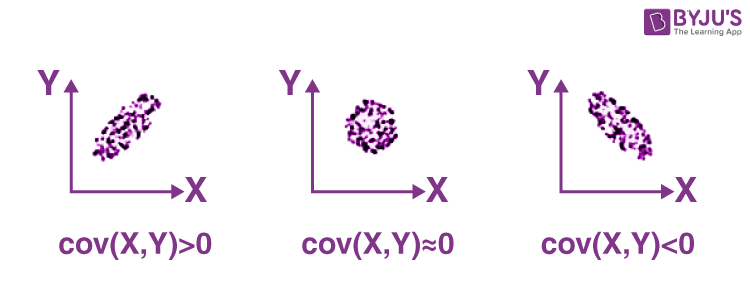

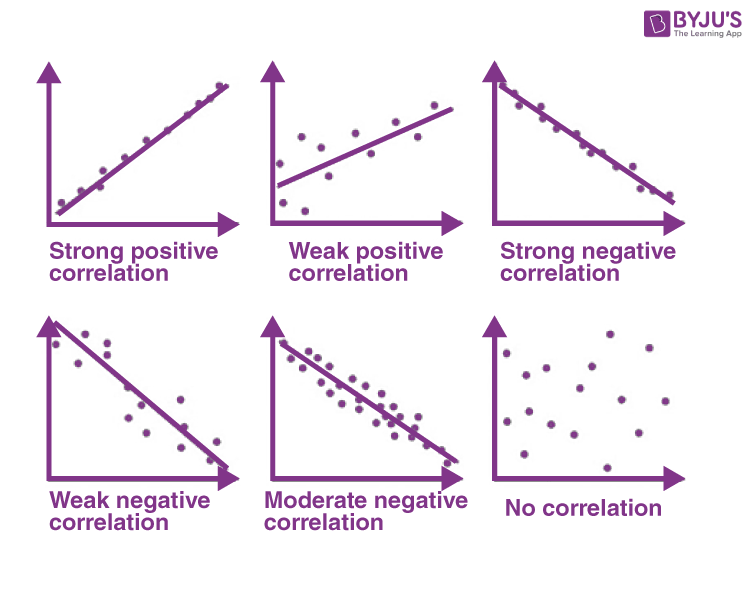

In [165]:
#! ipython id=631a9370002647c4ba7ffbf73e239c5f
returns.corr()

,AAPL,GOOG,IBM,MSFT
AAPL,1.000000,0.407919,0.386817,0.389695
GOOG,0.407919,1.000000,0.405099,0.465919
IBM,0.386817,0.405099,1.000000,0.499764
MSFT,0.389695,0.465919,0.499764,1.000000


In [166]:
#! ipython id=631a9370002647c4ba7ffbf73e239c5f
returns.cov()

,AAPL,GOOG,IBM,MSFT
AAPL,0.000277,0.000107,0.000078,0.000095
GOOG,0.000107,0.000251,0.000078,0.000108
IBM,0.000078,0.000078,0.000146,0.000089
MSFT,0.000095,0.000108,0.000089,0.000215


In [167]:
#! ipython id=668730d660dd4811aff520a5e870b532
returns.corrwith(returns["IBM"])

AAPL    0.386817
GOOG    0.405099
IBM     1.000000
MSFT    0.499764
dtype: float64

In [168]:
#! ipython id=07109c0f2f1a442f80c3cd9212519342
returns.corrwith(volume)

AAPL   -0.075565
GOOG   -0.007067
IBM    -0.204849
MSFT   -0.092950
dtype: float64

In [169]:
#! ipython id=90d33c8d9c4543029cad491971f29316
obj = pd.Series(["c", "a", "d", "a", "a", "b", "b", "c", "c"])

In [170]:
#! ipython id=18c2f28cf84c4223bb3a96445e2c53e4
uniques = obj.unique()
uniques

array(['c', 'a', 'd', 'b'], dtype=object)

In [171]:
#! ipython id=fb21f3506cb848c1a81c78348cb25847
obj.value_counts()

c    3
a    3
b    2
d    1
dtype: int64

In [172]:
#! ipython id=fcb65a23a9b749048c6c1d292392c8c5
pd.value_counts(obj.to_numpy(), sort=False)

c    3
a    3
d    1
b    2
dtype: int64

In [173]:
#! ipython id=045ee2714cf3417b98224a725cb9af71
obj
mask = obj.isin(["b", "c"])
mask
obj[mask]

0    c
5    b
6    b
7    c
8    c
dtype: object

In [174]:
#! ipython id=e2794101c4db4b8aae1a9d50f0e3b200
to_match = pd.Series(["c", "a", "b", "b", "c", "a"])
unique_vals = pd.Series(["c", "b", "a"])
indices = pd.Index(unique_vals).get_indexer(to_match)
indices

array([0, 2, 1, 1, 0, 2], dtype=int64)

In [175]:
#! ipython id=43b21608636349b881aadf2a75987ec7
data = pd.DataFrame({"Qu1": [1, 3, 4, 3, 4],
                     "Qu2": [2, 3, 1, 2, 3],
                     "Qu3": [1, 5, 2, 4, 4]})
data

,Qu1,Qu2,Qu3
0,1,2,1
1,3,3,5
2,4,1,2
3,3,2,4
4,4,3,4


In [176]:
#! ipython id=9ba487d2333f4a509874619fa6ee6026
data["Qu1"].value_counts().sort_index()

1    1
3    2
4    2
Name: Qu1, dtype: int64

In [177]:
#! ipython id=0e370e3e65534ed7938ffe5e7d19bb58
result = data.apply(pd.value_counts).fillna(0)
result

,Qu1,Qu2,Qu3
1,1.0,1.0,1.0
2,0.0,2.0,1.0
3,2.0,2.0,0.0
4,2.0,0.0,2.0
5,0.0,0.0,1.0


In [178]:
#! ipython id=2AF29992875D411F801CAC28587E96D9
data = pd.DataFrame({"a": [1, 1, 1, 2, 2], "b": [0, 0, 1, 0, 0]})
data
data.value_counts()

a  b
1  0    2
2  0    2
1  1    1
dtype: int64

In [181]:
csv_url = 'https://raw.githubusercontent.com/adylw/Tutorials/main/tutorial2Data.csv' #locate data
df = pd.read_csv(csv_url)
df

,Created by A. Wyngaard,Unnamed: 1,Unnamed: 2
0,in 2023 for AIN580S,NaN,NaN
1,year,SEasoN,COST
2,The values below are in the currency of Rands,NaN,NaN
3,2015,summer-winter,35
4,2016,autumn-winter,-99
5,2017,winter-spring,NaN
6,2022,summer-autumn,266
7,2023,spring-spring,420
8,2015,summer-winter,35
9,2018,autumn-spring,50
